### Import libraries

In [1]:
import joblib
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### Load the Data

In [2]:
X_train = joblib.load("../../data/processed/X_train_tfidf.pkl")
X_val = joblib.load("../../data/processed/X_val_tfidf.pkl")
X_test = joblib.load("../../data/processed/X_test_tfidf.pkl")

y_train = joblib.load("../../data/processed/y_train.pkl")
y_val = joblib.load("../../data/processed/y_val.pkl")
y_test = joblib.load("../../data/processed/y_test.pkl")

### Encode the Labels

In [3]:
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_val_encoded = encoder.transform(y_val)
y_test_encoded = encoder.transform(y_test)

In [4]:
print(dict(zip(encoder.classes_,
               encoder.transform(encoder.classes_))))

{'Negative': 0, 'Neutral': 1, 'Positive': 2}


### Build the Model

In [5]:
xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train_encoded)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'mlogloss'


### Training Accuracy

In [6]:
y_train_pred = xgb_model.predict(X_train)

train_accuracy = accuracy_score(
    y_train_encoded,
    y_train_pred
)

print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 0.9481


### Validation Accuracy

In [7]:
y_val_pred = xgb_model.predict(X_val)

val_accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred
)

print(f"Validation Accuracy: {val_accuracy:.4f}")

Validation Accuracy: 0.9348


### Test Accuracy

In [8]:
y_test_pred = xgb_model.predict(X_test)

test_accuracy = accuracy_score(
    y_test_encoded,
    y_test_pred
)

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.9353


### Print All Accuracies

In [9]:
print(f"Training Accuracy   : {train_accuracy:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Test Accuracy       : {test_accuracy:.4f}")

Training Accuracy   : 0.9481
Validation Accuracy : 0.9348
Test Accuracy       : 0.9353


### Classification Report

In [10]:
y_test_labels = encoder.inverse_transform(y_test_pred)

print(classification_report(
    y_test,
    y_test_labels
))

              precision    recall  f1-score   support

    Negative       0.86      0.38      0.53       347
     Neutral       0.73      0.11      0.19       388
    Positive       0.94      1.00      0.97      8223

    accuracy                           0.94      8958
   macro avg       0.84      0.50      0.56      8958
weighted avg       0.93      0.94      0.92      8958



### Confusion Matrix

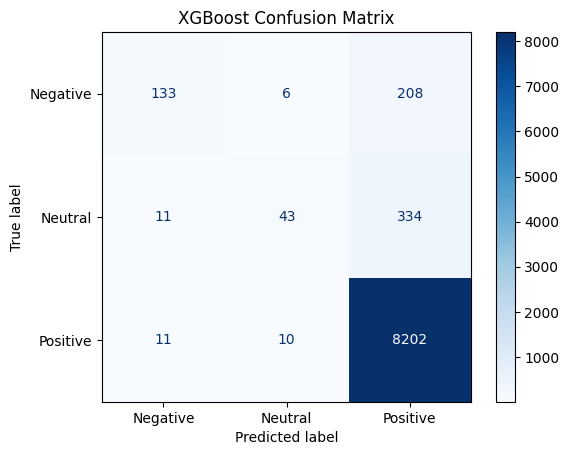

In [11]:
cm = confusion_matrix(
    y_test,
    y_test_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("XGBoost Confusion Matrix")

plt.show()

### Save the model

In [12]:
joblib.dump(
    xgb_model,
    "../../models/xgboost.pkl"
)

joblib.dump(
    encoder,
    "../../models/label_encoder.pkl"
)

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


### Report conclusion for XGBoost

The XGBoost classifier achieved a training accuracy of 94.81%, a validation accuracy of 93.48%, and a test accuracy of 93.53%. The small difference between the training and testing performance indicates that the model generalizes well to unseen data with minimal overfitting. Although Random Forest achieved a slightly higher test accuracy, XGBoost demonstrated a better balance between predictive performance and generalization.